In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Load the 4 raw tables
transactions = pd.read_csv("/content/drive/MyDrive/Analytics App/sales_transactions.csv", parse_dates=["transaction_date"])
customers = pd.read_csv("/content/drive/MyDrive/Analytics App/customers.csv", parse_dates=["customer_since"])
products = pd.read_csv("/content/drive/MyDrive/Analytics App/products.csv")
campaigns = pd.read_csv("/content/drive/MyDrive/Analytics App/campaigns.csv", parse_dates=["start_date", "end_date"])

customers["business_size"] = customers["business_size"].fillna("Individuals").replace(["N/A", "NA"], "Individuals")

# Build one merged "master" table joined with customer and product attributes
master = transactions.merge(customers, on="customer_id", how="left")
master = master.merge(products, on="product_id", how="left", suffixes=("", "_product"))

master["year_month"] = master["transaction_date"].dt.to_period("M").dt.to_timestamp()
master["year"] = master["transaction_date"].dt.year

print("Master shape:", master.shape)
print("Date range:", master.transaction_date.min().date(), "to", master.transaction_date.max().date())
master.head()

Master shape: (12922, 28)
Date range: 2023-01-01 to 2024-12-31


,transaction_id,transaction_date,customer_id,product_id,branch_id,channel,quantity,unit_price,discount_percentage,gross_revenue,...,location_category,business_size,product_name,category,standard_price,cost_price,margin_percentage,active_status,year_month,year
0,T100001,2023-01-01,C1107,P109,BR-Central,Branch,1,221.65,5,221.65,...,Urban,Individuals,Beauty Blue 10,Beauty & Personal Care,221.65,169.04,23.74,Active,2023-01-01,2023
1,T100002,2023-01-01,C1014,P108,BR-North,Online,2,159.08,0,318.16,...,Urban,Small,Apparel Since 9,Apparel,159.08,110.17,30.74,Active,2023-01-01,2023
2,T100003,2023-01-01,C1084,P121,BR-West,Online,4,26.85,5,107.40,...,Suburban,Individuals,Beauty Early 22,Beauty & Personal Care,26.85,15.50,42.28,Active,2023-01-01,2023
3,T100004,2023-01-01,C1104,P100,BR-South,Dealer,1,193.52,5,193.52,...,Suburban,Individuals,Electronics Purpose 1,Electronics,193.52,109.30,43.52,Active,2023-01-01,2023
4,T100005,2023-01-01,C1022,P129,BR-West,Online,2,32.16,15,64.32,...,Urban,Individuals,Office Science 30,Office Supplies,32.16,24.20,24.76,Discontinued,2023-01-01,2023


In [8]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12922 entries, 0 to 12921
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       12922 non-null  object        
 1   transaction_date     12922 non-null  datetime64[ns]
 2   customer_id          12922 non-null  object        
 3   product_id           12922 non-null  object        
 4   branch_id            12922 non-null  object        
 5   channel              12922 non-null  object        
 6   quantity             12922 non-null  int64         
 7   unit_price           12922 non-null  float64       
 8   discount_percentage  12922 non-null  int64         
 9   gross_revenue        12922 non-null  float64       
 10  net_revenue          12922 non-null  float64       
 11  cost                 12922 non-null  float64       
 12  gross_margin         12922 non-null  float64       
 13  payment_status       12922 non-

In [9]:
# Quick validation checks
issues = []
if master["customer_id"].isna().any():
    issues.append("Some transactions failed to join to a customer.")
if (master["net_revenue"] > master["gross_revenue"]).any():
    issues.append("Found net_revenue > gross_revenue (discount math issue).")
if master["net_revenue"].isna().any():
    issues.append("Nulls found in net_revenue.")

if issues:
    print("VALIDATION ISSUES FOUND:")
    for i in issues:
        print(" -", i)
else:
    print("Validation passed: no missing joins, no null revenue, discount math consistent.")

Validation passed: no missing joins, no null revenue, discount math consistent.


In [10]:
total_revenue = master["net_revenue"].sum()
total_margin = master["gross_margin"].sum()
margin_pct_of_revenue = round(100 * total_margin / total_revenue, 2)
average_order_value = round(master["net_revenue"].sum() / master["transaction_id"].nunique(), 2)

print(f"Total net revenue: {total_revenue:,.2f}")
print(f"Total gross margin: {total_margin:,.2f} ({margin_pct_of_revenue}% of revenue)")
print(f"Average order value: {average_order_value:,.2f}")

Total net revenue: 5,339,619.54
Total gross margin: 1,197,271.71 (22.42% of revenue)
Average order value: 413.22


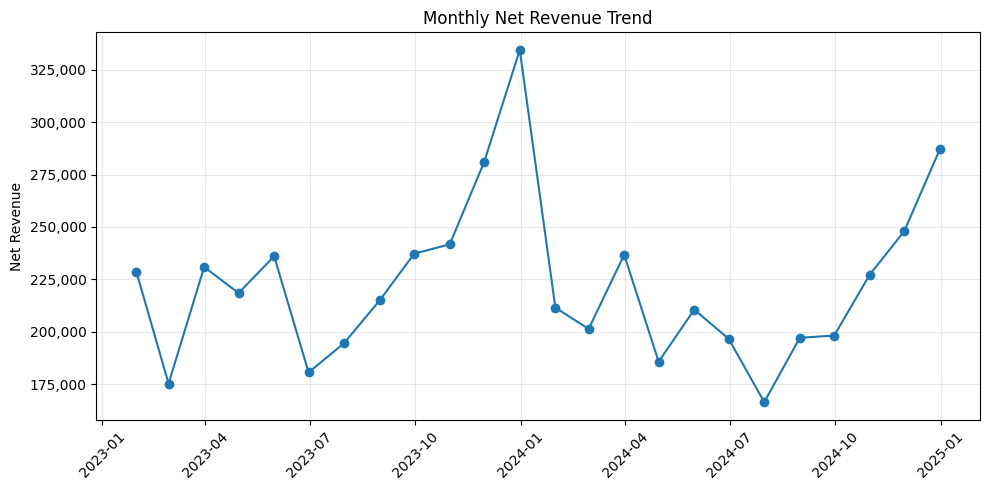

In [11]:
# Monthly revenue trend
trend = master.set_index("transaction_date").resample("ME")["net_revenue"].sum().to_frame()

fig, ax = plt.subplots()
ax.plot(trend.index, trend["net_revenue"], marker="o")
ax.set_title("Monthly Net Revenue Trend")
ax.set_ylabel("Net Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

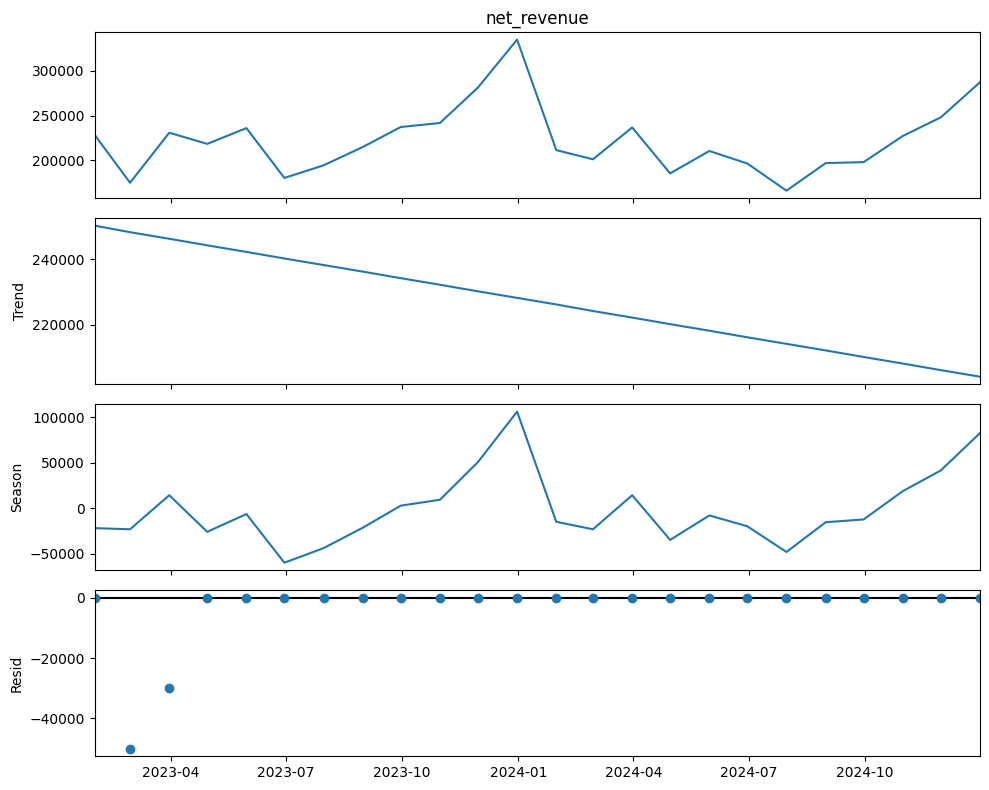

In [12]:
from statsmodels.tsa.seasonal import STL

# STL works best with a set frequency on your index
trend_series = trend["net_revenue"].asfreq("ME")

# Fit STL (robust=True helps handle outliers)
stl = STL(trend_series, period=12, robust=True)
res = stl.fit()

# Plot the STL results
fig = res.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

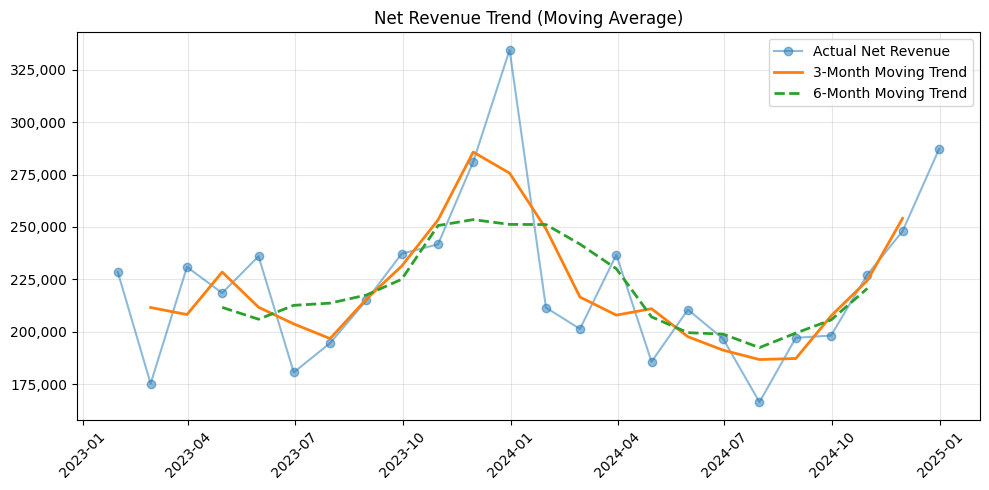

In [13]:
# 3-month and 6-month moving averages
trend["3M_MA"] = trend["net_revenue"].rolling(window=3, center=True).mean()
trend["6M_MA"] = trend["net_revenue"].rolling(window=6, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(trend.index, trend["net_revenue"], label="Actual Net Revenue", alpha=0.5, marker="o")
plt.plot(trend.index, trend["3M_MA"], label="3-Month Moving Trend", linewidth=2)
plt.plot(trend.index, trend["6M_MA"], label="6-Month Moving Trend", linewidth=2, linestyle="--")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.title("Net Revenue Trend (Moving Average)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

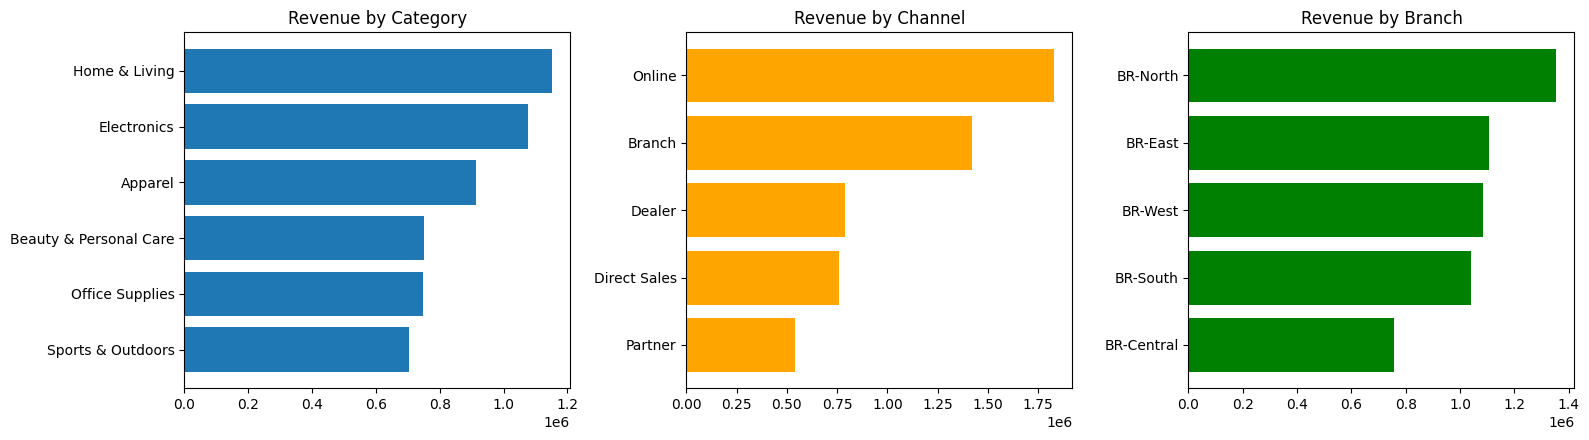

In [14]:
# Revenue by category / channel / branch
revenue_by_category = master.groupby("category")["net_revenue"].sum().sort_values(ascending=False).reset_index()
revenue_by_channel = master.groupby("channel")["net_revenue"].sum().sort_values(ascending=False).reset_index()
revenue_by_branch = master.groupby("branch_id")["net_revenue"].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].barh(revenue_by_category["category"], revenue_by_category["net_revenue"])
axes[0].set_title("Revenue by Category")
axes[0].invert_yaxis()

axes[1].barh(revenue_by_channel["channel"], revenue_by_channel["net_revenue"], color="orange")
axes[1].set_title("Revenue by Channel")
axes[1].invert_yaxis()

axes[2].barh(revenue_by_branch["branch_id"], revenue_by_branch["net_revenue"], color="green")
axes[2].set_title("Revenue by Branch")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


In [15]:
# --- RFM calculation ---
snapshot_date = master["transaction_date"].max() + pd.Timedelta(days=1)

rfm = master.groupby("customer_id").agg(
    recency=("transaction_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("transaction_id", "nunique"),
    monetary=("net_revenue", "sum"),
).reset_index()

# Quantile scoring 1-5 (5 = best). Recency inverted: lower recency = better.
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,C1000,1,118,"52,724.48",5,4,5,14
1,C1001,1,116,"45,288.27",5,4,3,12
2,C1002,1,108,"44,703.06",5,3,3,11
3,C1003,8,117,"46,284.82",2,4,3,9
4,C1004,3,108,"40,522.62",4,3,2,9


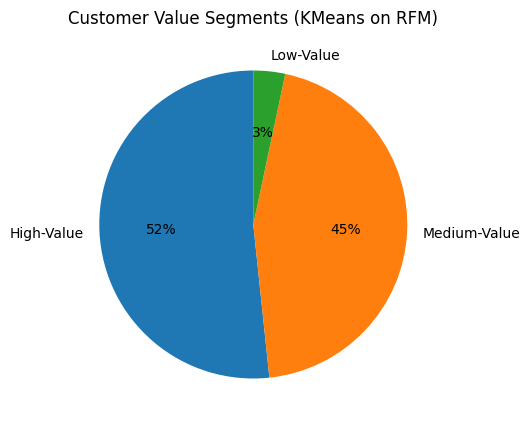

,count
value_segment,
High-Value,62
Medium-Value,54
Low-Value,4


In [16]:
# --- KMeans segmentation on RFM ---
features = rfm[["recency", "frequency", "monetary"]].copy()
scaled = StandardScaler().fit_transform(features)

km = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm["cluster"] = km.fit_predict(scaled)

# Rank clusters by average monetary value to label them meaningfully
cluster_rank = rfm.groupby("cluster")["monetary"].mean().sort_values(ascending=False).index
label_map = {cluster_rank[0]: "High-Value", cluster_rank[1]: "Medium-Value", cluster_rank[-1]: "Low-Value"}
rfm["value_segment"] = rfm["cluster"].map(label_map)
rfm = rfm.drop(columns="cluster")

seg_counts = rfm["value_segment"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(seg_counts, labels=seg_counts.index, autopct="%1.0f%%", startangle=90)
ax.set_title("Customer Value Segments (KMeans on RFM)")
plt.show()

seg_counts


In [17]:
# --- CLV estimate ---
# Simple CLV = avg order value * purchase frequency per year * assumed lifespan
assumed_lifespan_years = 3
obs_years = 2  # dataset spans 2 years

avg_order_value_per_cust = rfm["monetary"] / rfm["frequency"]
purchases_per_year = rfm["frequency"] / obs_years
rfm["estimated_clv"] = (avg_order_value_per_cust * purchases_per_year * assumed_lifespan_years).round(2)

# --- Repeat purchase behavior ---
repeat_customers = (rfm["frequency"] > 1).sum()
one_time_customers = (rfm["frequency"] == 1).sum()
repeat_rate_pct = round(100 * repeat_customers / len(rfm), 1)

print({"repeat_customers": int(repeat_customers), "one_time_customers": int(one_time_customers),
       "repeat_rate_pct": repeat_rate_pct})

{'repeat_customers': 120, 'one_time_customers': 0, 'repeat_rate_pct': np.float64(100.0)}


In [18]:
# --- Top customers ---
print("Top 10 customers by revenue:")
top_customers = rfm.sort_values("monetary", ascending=False).head(10)
display(top_customers[["customer_id", "monetary", "frequency", "value_segment", "estimated_clv"]])


Top 10 customers by revenue:


,customer_id,monetary,frequency,value_segment,estimated_clv
29,C1029,"60,650.65",138,High-Value,"90,975.98"
116,C1116,"57,377.09",125,High-Value,"86,065.64"
92,C1092,"55,258.18",135,High-Value,"82,887.27"
23,C1023,"55,144.46",115,High-Value,"82,716.69"
37,C1037,"53,223.46",115,High-Value,"79,835.19"
58,C1058,"53,172.69",128,High-Value,"79,759.04"
57,C1057,"52,900.65",114,High-Value,"79,350.98"
0,C1000,"52,724.48",118,High-Value,"79,086.72"
102,C1102,"52,007.05",129,High-Value,"78,010.58"
52,C1052,"51,839.16",111,High-Value,"77,758.74"


In [19]:
# --- Inactive customers (reactivation candidates) ---
# Ranked directly by past monetary value rather than the cluster label:
# KMeans' recency-driven clustering can mask high past spenders who've
# recently gone quiet. Ranking by monetary value is what actually answers
# the business question: "who is high-value but has stopped buying?"
inactive = rfm[rfm["recency"] > 90].sort_values("monetary", ascending=False)
print(f"{len(inactive)} customers inactive > 90 days")
print("\nTop reactivation candidates (ranked by historical spend):")
display(inactive[["customer_id", "recency", "monetary", "estimated_clv", "value_segment"]].head(10))


4 customers inactive > 90 days

Top reactivation candidates (ranked by historical spend):


,customer_id,recency,monetary,estimated_clv,value_segment
66,C1066,190,"42,194.88","63,292.32",Low-Value
61,C1061,148,"37,990.42","56,985.63",Low-Value
118,C1118,135,"36,644.97","54,967.46",Low-Value
109,C1109,185,"28,363.56","42,545.34",Low-Value


In [20]:
# --- Top products by revenue ---
top_products = (master.groupby(["product_id", "product_name"])["net_revenue"]
                .sum().sort_values(ascending=False).reset_index().head(10))
print("Top 10 products by revenue:")
display(top_products)


Top 10 products by revenue:


,product_id,product_name,net_revenue
0,P117,Office Almost 18,"452,237.67"
1,P125,Home Option 26,"426,645.29"
2,P126,Apparel Decide 27,"402,619.60"
3,P106,Electronics Dog 7,"378,491.90"
4,P101,Home Brother 2,"331,166.88"
5,P127,Beauty Sense 28,"278,429.18"
6,P110,Sports Require 11,"269,504.05"
7,P104,Sports Face 5,"261,197.22"
8,P114,Apparel Begin 15,"245,148.63"
9,P124,Electronics Agreement 25,"242,931.64"


In [21]:
# --- Low-margin products ---
prod_agg = master.groupby(["product_id", "product_name"]).agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
).reset_index()
prod_agg["margin_pct"] = 100 * prod_agg["gross_margin"] / prod_agg["net_revenue"]

print("Lowest-margin products (bottom 10 by margin %):")
display(prod_agg.sort_values("margin_pct").head(10))


Lowest-margin products (bottom 10 by margin %):


,product_id,product_name,net_revenue,gross_margin,margin_pct
15,P115,Beauty Performance 16,"234,590.55","-4,456.25",-1.90
7,P107,Home Chair 8,"82,443.04","-1,151.34",-1.40
2,P102,Apparel Ago 3,"77,762.07",-843.03,-1.08
22,P122,Sports Mouth 23,"107,750.52",224.28,0.21
27,P127,Beauty Sense 28,"278,429.18","6,067.02",2.18
14,P114,Apparel Begin 15,"245,148.63","28,492.48",11.62
18,P118,Electronics All 19,"122,239.87","16,111.47",13.18
10,P110,Sports Require 11,"269,504.05","38,662.91",14.35
24,P124,Electronics Agreement 25,"242,931.64","38,691.64",15.93
6,P106,Electronics Dog 7,"378,491.90","62,388.32",16.48


50.0% of products generate 80% of total revenue


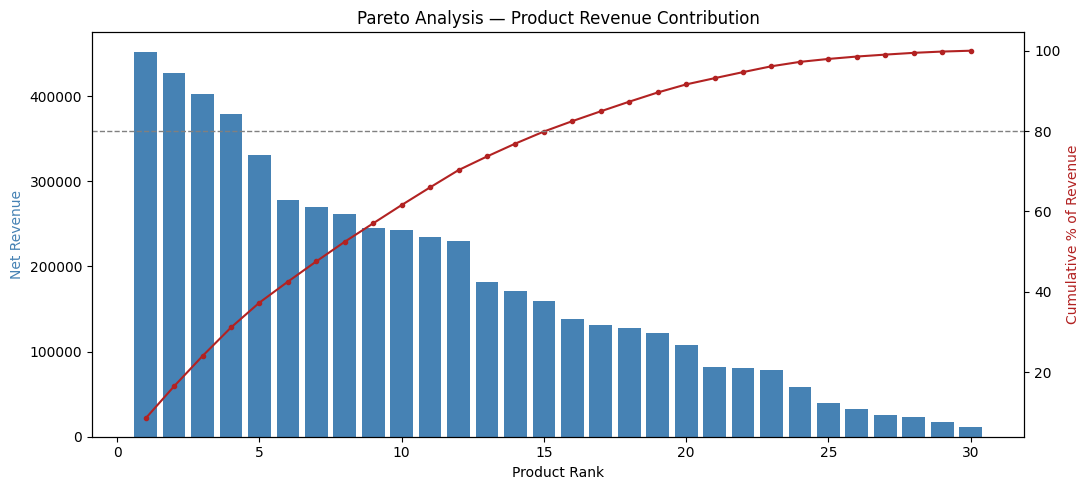

In [22]:
# --- Pareto analysis ---
prod_rev = master.groupby("product_id")["net_revenue"].sum().sort_values(ascending=False)
cum_pct = (100 * prod_rev.cumsum() / prod_rev.sum()).round(2)
pareto_df = pd.DataFrame({"net_revenue": prod_rev, "cumulative_pct": cum_pct}).reset_index()
pareto_df["product_rank"] = range(1, len(pareto_df) + 1)

n_products = len(pareto_df)
pct_for_80 = round(100 * (pareto_df["cumulative_pct"] <= 80).sum() / n_products, 1)
print(f"{pct_for_80}% of products generate 80% of total revenue")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(pareto_df["product_rank"], pareto_df["net_revenue"], color="steelblue")
ax1.set_xlabel("Product Rank")
ax1.set_ylabel("Net Revenue", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(pareto_df["product_rank"], pareto_df["cumulative_pct"], color="firebrick", marker="o", markersize=3)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative % of Revenue", color="firebrick")

plt.title("Pareto Analysis — Product Revenue Contribution")
plt.tight_layout()
plt.show()


In [23]:
# --- Channel comparison ---
channel_comparison = master.groupby("channel").agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()
channel_comparison["avg_margin_pct"] = round(
    100 * channel_comparison["gross_margin"] / channel_comparison["net_revenue"], 2
)
channel_comparison = channel_comparison.sort_values("net_revenue", ascending=False)

print("Channel comparison:")
display(channel_comparison)


Channel comparison:


,channel,net_revenue,gross_margin,transactions,avg_margin_pct
3,Online,"1,827,676.97","405,274.88",4429,22.17
0,Branch,"1,422,183.82","326,813.15",3360,22.98
1,Dealer,"791,132.55","173,575.89",1956,21.94
2,Direct Sales,"760,757.73","170,388.48",1890,22.40
4,Partner,"537,868.47","121,219.31",1287,22.54


,discount_band,net_revenue,gross_margin,transactions,avg_margin_pct
0,0%,"2,325,452.11","622,084.27",5249,26.75
1,1-5%,"1,279,215.02","301,197.82",2960,23.55
2,6-10%,"847,848.70","164,833.00",2085,19.44
3,11-15%,"530,840.05","80,384.13",1308,15.14
4,16-20%,"197,893.50","22,256.13",623,11.25
5,21-25%,"118,033.16","4,705.62",453,3.99
6,26%+,"40,337.00","1,810.74",244,4.49


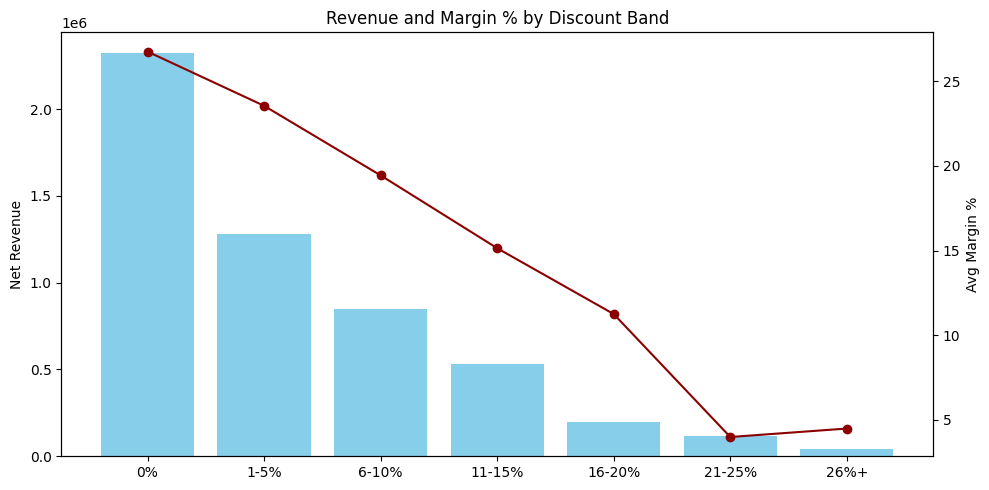

In [24]:
# --- Discount bands ---
bins = [-0.1, 0, 5, 10, 15, 20, 25, 100]
labels = ["0%", "1-5%", "6-10%", "11-15%", "16-20%", "21-25%", "26%+"]
master["discount_band"] = pd.cut(master["discount_percentage"], bins=bins, labels=labels)

bands = master.groupby("discount_band", observed=True).agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()
bands["avg_margin_pct"] = round(100 * bands["gross_margin"] / bands["net_revenue"], 2)
display(bands)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(bands["discount_band"].astype(str), bands["net_revenue"], color="skyblue", label="Net Revenue")
ax1.set_ylabel("Net Revenue")

ax2 = ax1.twinx()
ax2.plot(bands["discount_band"].astype(str), bands["avg_margin_pct"], color="darkred", marker="o", label="Avg Margin %")
ax2.set_ylabel("Avg Margin %")

plt.title("Revenue and Margin % by Discount Band")
plt.tight_layout()
plt.show()


In [25]:
# --- Correlation: discount % vs margin % ---
master["margin_pct"] = 100 * master["gross_margin"] / master["net_revenue"]
corr, p_value = stats.pearsonr(master["discount_percentage"], master["margin_pct"])
print(f"Discount % vs margin % correlation: {corr:.3f} (p-value {p_value:.5f})")

# --- OLS regression: quantity ~ discount_percentage ---
X = sm.add_constant(master["discount_percentage"])
y = master["quantity"]
model = sm.OLS(y, X).fit()
print(f"\nOLS: quantity ~ discount_percentage")
print(f"coef = {model.params['discount_percentage']:.4f}  "
      f"p-value = {model.pvalues['discount_percentage']:.4f}  R² = {model.rsquared:.4f}")


Discount % vs margin % correlation: -0.364 (p-value 0.00000)

OLS: quantity ~ discount_percentage
coef = -0.0121  p-value = 0.0000  R² = 0.0060


In [26]:
# --- Per-product discount-vs-quantity correlation ---
# Flags products where higher discounting is NOT correlated with more volume
results = []
for pid, grp in master.groupby("product_id"):
    if grp["discount_percentage"].nunique() < 2 or len(grp) < 10:
        continue
    c, p = stats.pearsonr(grp["discount_percentage"], grp["quantity"])
    results.append({
        "product_id": pid,
        "n_transactions": len(grp),
        "discount_qty_corr": round(c, 3),
        "p_value": round(p, 4),
        "avg_discount": round(grp["discount_percentage"].mean(), 1),
    })
corr_df = pd.DataFrame(results)

# Above-average discounting (>=13%) with flat or negative correlation to volume
over_discounted = corr_df[(corr_df["avg_discount"] >= 13) & (corr_df["discount_qty_corr"] <= 0.15)]
over_discounted = over_discounted.sort_values("avg_discount", ascending=False)

print("Products where higher discounting does NOT correlate with more volume:")
display(over_discounted)


Products where higher discounting does NOT correlate with more volume:


,product_id,n_transactions,discount_qty_corr,p_value,avg_discount
5,P105,427,-0.34,0.00,16.50
12,P112,462,-0.30,0.00,15.20
19,P119,457,-0.29,0.00,14.50


Holdout forecast error — MAE: 50,909.76  RMSE: 56,144.41  MAPE: 19.35%


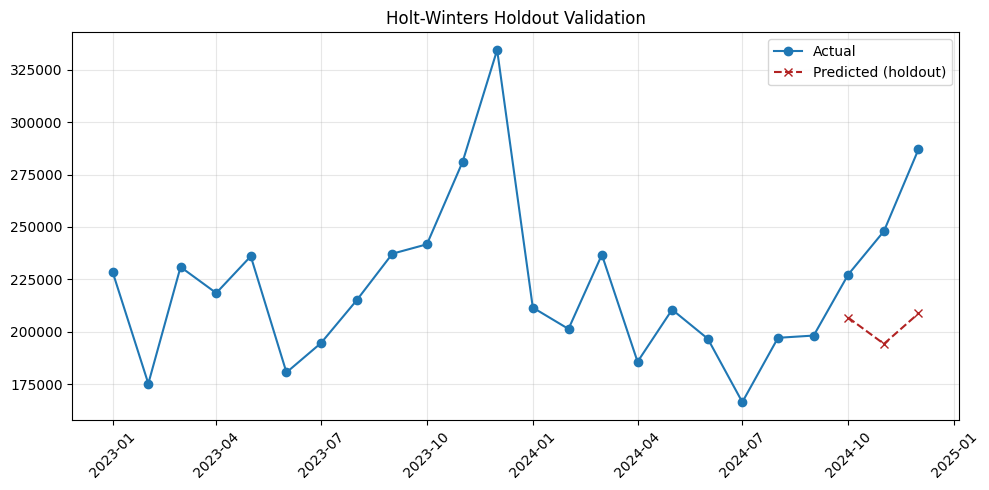

In [27]:
# Monthly revenue series
series = master.set_index("transaction_date").resample("ME")["net_revenue"].sum()
series.index = series.index.to_period("M").to_timestamp()

holdout_months = 3
train, test = series.iloc[:-holdout_months], series.iloc[-holdout_months:]

seasonal_periods = 12
if len(train) < 2 * seasonal_periods:
    seasonal_periods = max(3, len(train) // 3)  # fallback for limited history

hw_model = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=seasonal_periods,
    initialization_method="estimated",
).fit()
pred = hw_model.forecast(len(test))

mae = np.mean(np.abs(test.values - pred.values))
rmse = np.sqrt(np.mean((test.values - pred.values) ** 2))
mape = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
print(f"Holdout forecast error — MAE: {mae:,.2f}  RMSE: {rmse:,.2f}  MAPE: {mape:.2f}%")

fig, ax = plt.subplots()
ax.plot(series.index, series.values, label="Actual", marker="o")
ax.plot(test.index, pred.values, label="Predicted (holdout)", marker="x", linestyle="--", color="firebrick")
ax.legend()
ax.set_title("Holt-Winters Holdout Validation")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,base_case,low_case,best_case
2025-01-01,"189,173.35","170,256.02","208,090.69"
2025-02-01,"179,847.82","161,863.04","197,832.60"
2025-03-01,"216,629.82","194,966.84","238,292.81"
2025-04-01,"166,752.47","150,077.23","183,427.72"
2025-05-01,"192,581.24","173,323.12","211,839.37"
2025-06-01,"180,982.05","162,883.84","199,080.25"


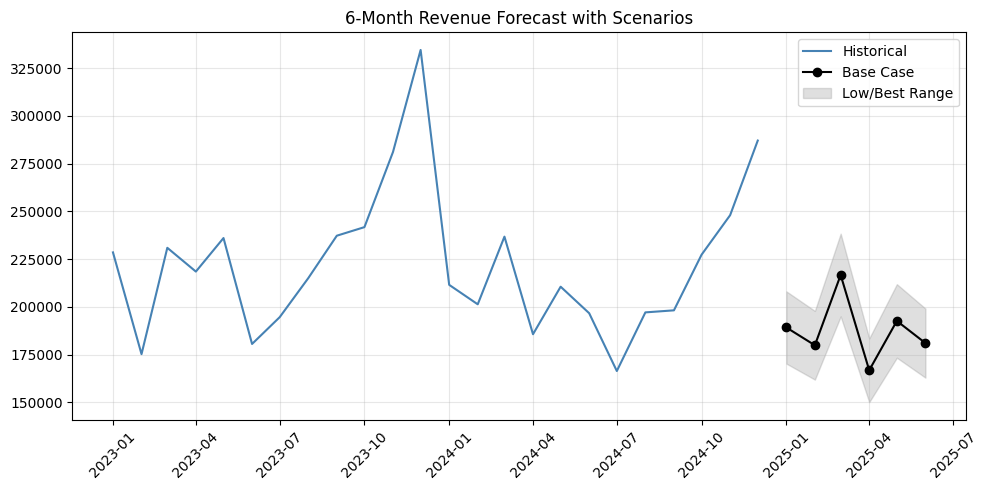

In [28]:
# --- 6-month forward forecast on full history, with scenario bands ---
future_model = ExponentialSmoothing(
    series, trend="add", seasonal="add", seasonal_periods=12,
    initialization_method="estimated",
).fit()
future = future_model.forecast(6)

scenarios = pd.DataFrame({
    "base_case": future.round(2),
    "low_case": (future * 0.90).round(2),
    "best_case": (future * 1.10).round(2),
})
display(scenarios)

fig, ax = plt.subplots()
ax.plot(series.index, series.values, label="Historical", color="steelblue")
ax.plot(scenarios.index, scenarios["base_case"], label="Base Case", color="black", marker="o")
ax.fill_between(scenarios.index, scenarios["low_case"], scenarios["best_case"], color="gray", alpha=0.25, label="Low/Best Range")
ax.legend()
ax.set_title("6-Month Revenue Forecast with Scenarios")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
# --- Overdue revenue ---
overdue_txns = master[master["payment_status"].isin(["Overdue", "Partially Paid"])]
overdue_by_segment = overdue_txns.groupby("segment")["net_revenue"].sum().sort_values(ascending=False)
total_overdue = overdue_txns["net_revenue"].sum()
pct_of_total_revenue = round(100 * total_overdue / total_revenue, 2)

print(f"Total overdue/partially-paid revenue: {total_overdue:,.2f} ({pct_of_total_revenue}% of total revenue)")
display(overdue_by_segment.reset_index())


Total overdue/partially-paid revenue: 837,469.95 (15.68% of total revenue)


,segment,net_revenue
0,Standard,"319,033.97"
1,Budget,"257,351.58"
2,Premium,"131,896.70"
3,New,"129,187.70"


,customer_type,overdue_rate_pct
2,SME,30.40
0,Corporate,10.50
1,Individual,9.70


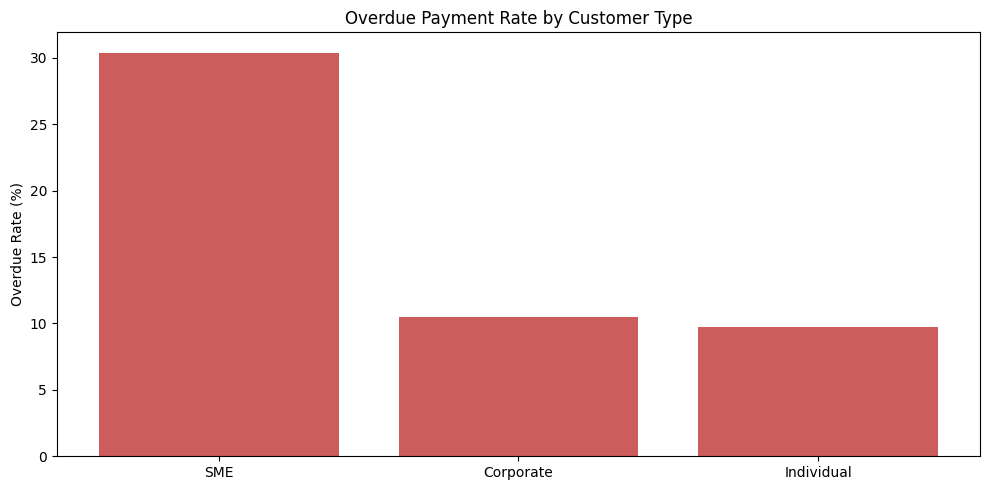

In [30]:
# --- Overdue rate by customer type ---
master["is_overdue"] = master["payment_status"].isin(["Overdue", "Partially Paid"])
overdue_by_type = master.groupby("customer_type").agg(
    overdue_rate_pct=("is_overdue", lambda x: round(100 * x.mean(), 1)),
).reset_index().sort_values("overdue_rate_pct", ascending=False)

display(overdue_by_type)

fig, ax = plt.subplots()
ax.bar(overdue_by_type["customer_type"], overdue_by_type["overdue_rate_pct"], color="indianred")
ax.set_ylabel("Overdue Rate (%)")
ax.set_title("Overdue Payment Rate by Customer Type")
plt.tight_layout()
plt.show()


In [31]:
# --- Low-margin sales ---
low_margin = master[master["margin_pct"] < 10]
low_margin_summary = low_margin.groupby("product_id").agg(
    net_revenue=("net_revenue", "sum"),
    avg_margin_pct=("margin_pct", "mean"),
    n_transactions=("transaction_id", "nunique"),
).sort_values("net_revenue", ascending=False).reset_index()

print("Low-margin sales by product (revenue at risk):")
display(low_margin_summary.head(10))


Low-margin sales by product (revenue at risk):


,product_id,net_revenue,avg_margin_pct,n_transactions
0,P127,"278,429.18",1.36,470
1,P115,"234,590.55",-2.25,402
2,P122,"107,750.52",-0.29,433
3,P107,"82,443.04",-1.82,437
4,P102,"77,762.07",-1.74,473
5,P114,"66,767.16",2.93,131
6,P106,"58,735.88",4.31,75
7,P119,"48,406.71",1.02,143
8,P118,"37,927.60",5.12,144
9,P110,"36,433.76",2.39,80


,leakage_area,estimated_value
0,Overdue / partially paid revenue,"837,469.95"
1,Excessive discounting (>=20%) - discount value...,"106,105.11"
2,Low-margin sales (<10% margin) - revenue at risk,"1,091,018.86"


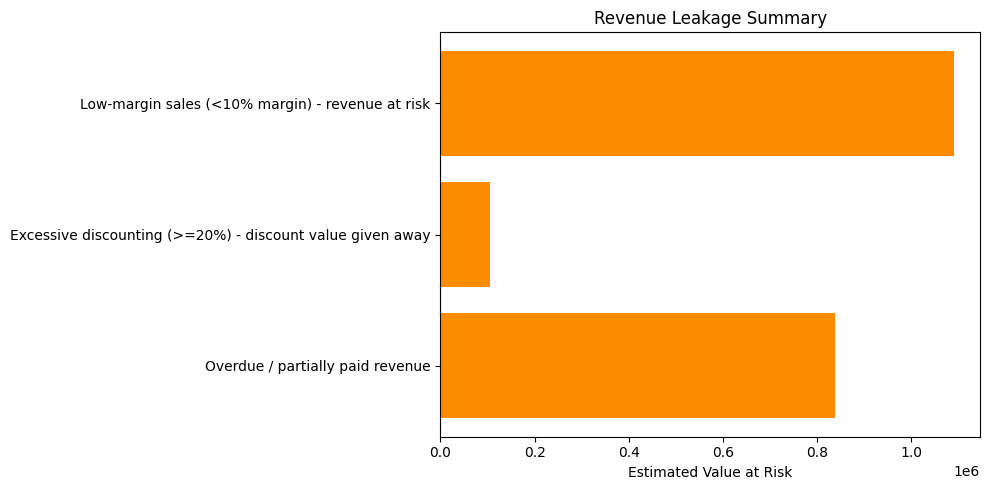

In [32]:
# --- Excessive discounting ---
excess_disc_txns = master[master["discount_percentage"] >= 20]
excess_disc_value = (excess_disc_txns["gross_revenue"] - excess_disc_txns["net_revenue"]).sum()

# --- Leakage summary rollup ---
leakage_summary = pd.DataFrame([
    {"leakage_area": "Overdue / partially paid revenue", "estimated_value": round(total_overdue, 2)},
    {"leakage_area": "Excessive discounting (>=20%) - discount value given away", "estimated_value": round(excess_disc_value, 2)},
    {"leakage_area": "Low-margin sales (<10% margin) - revenue at risk", "estimated_value": round(low_margin_summary['net_revenue'].sum(), 2)},
])
display(leakage_summary)

fig, ax = plt.subplots()
ax.barh(leakage_summary["leakage_area"], leakage_summary["estimated_value"], color="darkorange")
ax.set_xlabel("Estimated Value at Risk")
ax.set_title("Revenue Leakage Summary")
plt.tight_layout()
plt.show()


## Module 5: Revenue Forecasting (Isuru)

In [33]:
# --- Monthly revenue series ---
monthly_revenue = master.set_index("transaction_date").resample("ME")["net_revenue"].sum()
monthly_revenue.index = monthly_revenue.index.to_period("M").to_timestamp()

print(monthly_revenue)

transaction_date
2023-01-01   228,479.69
2023-02-01   175,195.51
2023-03-01   230,879.04
2023-04-01   218,435.20
2023-05-01   235,996.21
2023-06-01   180,527.87
2023-07-01   194,554.62
2023-08-01   214,980.63
2023-09-01   237,213.72
2023-10-01   241,706.00
2023-11-01   281,056.62
2023-12-01   334,494.91
2024-01-01   211,483.60
2024-02-01   201,294.71
2024-03-01   236,724.49
2024-04-01   185,629.31
2024-05-01   210,515.32
2024-06-01   196,618.42
2024-07-01   166,362.03
2024-08-01   197,064.98
2024-09-01   198,135.35
2024-10-01   227,271.05
2024-11-01   247,961.26
2024-12-01   287,039.00
Freq: MS, Name: net_revenue, dtype: float64


In [35]:
# --- Fit on full history (not enough data for a holdout with 12-month seasonality) ---
model = ExponentialSmoothing(
    monthly_revenue, trend="add", seasonal="add", seasonal_periods=12,
    initialization_method="estimated",
).fit()

fitted = model.fittedvalues

mae = np.mean(np.abs(monthly_revenue.values - fitted.values))
rmse = np.sqrt(np.mean((monthly_revenue.values - fitted.values) ** 2))
mape = np.mean(np.abs((monthly_revenue.values - fitted.values) / monthly_revenue.values)) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  12,249.30
RMSE: 14,326.19
MAPE: 5.67%


,base_case,low_case,best_case
2025-01-01,"189,173.35","170,256.02","208,090.69"
2025-02-01,"179,847.82","161,863.04","197,832.60"
2025-03-01,"216,629.82","194,966.84","238,292.81"
2025-04-01,"166,752.47","150,077.23","183,427.72"
2025-05-01,"192,581.24","173,323.12","211,839.37"
2025-06-01,"180,982.05","162,883.84","199,080.25"


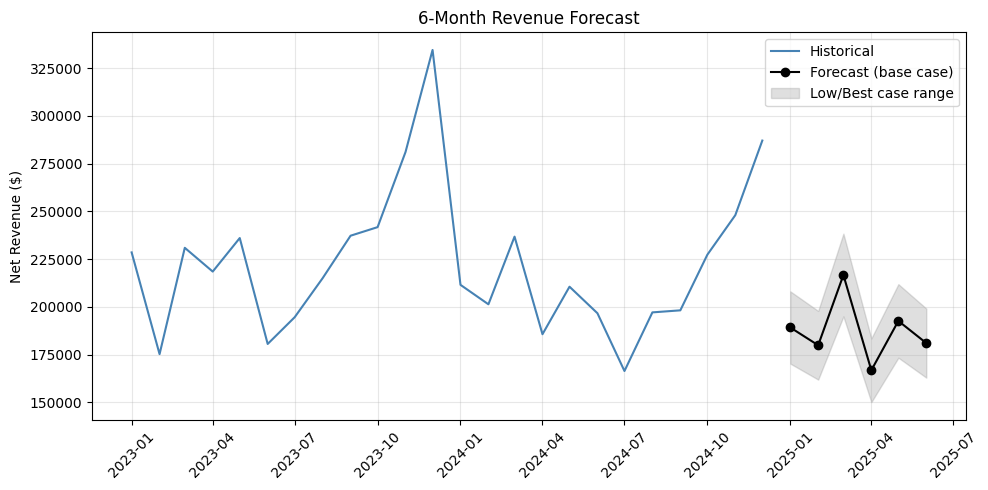

In [36]:
# --- Forecast next 6 months with scenarios ---
forecast = model.forecast(6)

scenarios = pd.DataFrame({
    "base_case": forecast.round(2),
    "low_case": (forecast * 0.90).round(2),
    "best_case": (forecast * 1.10).round(2),
})
display(scenarios)

fig, ax = plt.subplots()
ax.plot(monthly_revenue.index, monthly_revenue.values, label="Historical", color="steelblue")
ax.plot(scenarios.index, scenarios["base_case"], label="Forecast (base case)", color="black", marker="o")
ax.fill_between(scenarios.index, scenarios["low_case"], scenarios["best_case"], color="gray", alpha=0.25, label="Low/Best case range")
ax.legend()
ax.set_title("6-Month Revenue Forecast")
ax.set_ylabel("Net Revenue ($)")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Module 6: Revenue Leakage and Underperformance (Isuru)

In [37]:
# --- Overdue / partially paid revenue ---
overdue_txns = master[master["payment_status"].isin(["Overdue", "Partially Paid"])]
total_overdue = overdue_txns["net_revenue"].sum()
pct_of_total = 100 * total_overdue / master["net_revenue"].sum()

print(f"Total overdue/partially-paid revenue: {total_overdue:,.2f} ({pct_of_total:.2f}% of total revenue)")

overdue_by_type = master.groupby("customer_type")["payment_status"].apply(
    lambda x: 100 * x.isin(["Overdue", "Partially Paid"]).mean()
).round(1).sort_values(ascending=False)
print("\nOverdue rate by customer type (%):")
print(overdue_by_type)

Total overdue/partially-paid revenue: 837,469.95 (15.68% of total revenue)

Overdue rate by customer type (%):
customer_type
SME          30.40
Corporate    10.50
Individual    9.70
Name: payment_status, dtype: float64


In [38]:
# --- Excessive discounting ---
excess_disc_txns = master[master["discount_percentage"] >= 20]
excess_disc_value = (excess_disc_txns["gross_revenue"] - excess_disc_txns["net_revenue"]).sum()
pct_of_txns = 100 * len(excess_disc_txns) / len(master)

print(f"Transactions with >=20% discount: {len(excess_disc_txns)} ({pct_of_txns:.1f}% of all transactions)")
print(f"Discount value given away on these transactions: {excess_disc_value:,.2f}")

# Per-product: heavy discount with no volume lift
product_disc = master.groupby("product_id").agg(
    avg_discount_pct=("discount_percentage", "mean"),
    avg_quantity=("quantity", "mean"),
    n_transactions=("transaction_id", "nunique"),
).reset_index()

flagged = []
for pid in product_disc["product_id"]:
    sub = master[master["product_id"] == pid]
    if sub["discount_percentage"].std() > 0:
        corr, pval = stats.pearsonr(sub["discount_percentage"], sub["quantity"])
        if sub["discount_percentage"].mean() > 12 and corr < 0 and pval < 0.05:
            flagged.append({"product_id": pid, "avg_discount_pct": round(sub["discount_percentage"].mean(),2),
                             "corr": round(corr,2), "p_value": round(pval,4)})

flagged_df = pd.DataFrame(flagged)
print(f"\n{len(flagged_df)} product(s) flagged as over-discounted (heavy discount, no volume lift):")
display(flagged_df)

Transactions with >=20% discount: 1320 (10.2% of all transactions)
Discount value given away on these transactions: 106,105.11

3 product(s) flagged as over-discounted (heavy discount, no volume lift):


,product_id,avg_discount_pct,corr,p_value
0,P105,16.45,-0.34,0.00
1,P112,15.17,-0.30,0.00
2,P119,14.50,-0.29,0.00


In [39]:
# --- Low-margin sales ---
low_margin = master[master["margin_pct"] < 10]
low_margin_summary = low_margin.groupby("product_id").agg(
    net_revenue=("net_revenue", "sum"),
    avg_margin_pct=("margin_pct", "mean"),
    n_transactions=("transaction_id", "nunique"),
).sort_values("net_revenue", ascending=False).reset_index()

print(f"Products with <10% margin: {len(low_margin_summary)}")
print(f"Total net revenue at thin/negative margin: {low_margin_summary['net_revenue'].sum():,.2f}")
display(low_margin_summary.head(10))

Products with <10% margin: 19
Total net revenue at thin/negative margin: 1,091,018.86


,product_id,net_revenue,avg_margin_pct,n_transactions
0,P127,"278,429.18",1.36,470
1,P115,"234,590.55",-2.25,402
2,P122,"107,750.52",-0.29,433
3,P107,"82,443.04",-1.82,437
4,P102,"77,762.07",-1.74,473
5,P114,"66,767.16",2.93,131
6,P106,"58,735.88",4.31,75
7,P119,"48,406.71",1.02,143
8,P118,"37,927.60",5.12,144
9,P110,"36,433.76",2.39,80


In [40]:
# --- Inactive customers (recency > 90 days) ---
reference_date = master["transaction_date"].max()
customer_last_purchase = master.groupby("customer_id").agg(
    last_purchase=("transaction_date", "max"),
    total_spend=("net_revenue", "sum"),
).reset_index()
customer_last_purchase["days_since_last_purchase"] = (reference_date - customer_last_purchase["last_purchase"]).dt.days

inactive = customer_last_purchase[customer_last_purchase["days_since_last_purchase"] > 90].sort_values("total_spend", ascending=False)

print(f"{len(inactive)} customers inactive for 90+ days")
print(f"Combined historic spend of inactive customers: {inactive['total_spend'].sum():,.2f}")
display(inactive.head(10))

4 customers inactive for 90+ days
Combined historic spend of inactive customers: 145,193.83


,customer_id,last_purchase,total_spend,days_since_last_purchase
66,C1066,2024-06-25,"42,194.88",189
61,C1061,2024-08-06,"37,990.42",147
118,C1118,2024-08-19,"36,644.97",134
109,C1109,2024-06-30,"28,363.56",184


In [41]:
# --- Weak branches / channels ---
branch_rev = master.groupby("branch_id")["net_revenue"].sum().sort_values(ascending=False)
channel_rev = master.groupby("channel")["net_revenue"].sum().sort_values(ascending=False)

branch_flag = branch_rev[branch_rev < 0.85 * branch_rev.mean()]
channel_flag = channel_rev[channel_rev < 0.85 * channel_rev.mean()]

print("Branch revenue:")
print(branch_rev)
print(f"\nBranches >15% below average ({branch_rev.mean():,.2f}):")
print(branch_flag)

print("\nChannel revenue:")
print(channel_rev)
print(f"\nChannels >15% below average ({channel_rev.mean():,.2f}):")
print(channel_flag)

Branch revenue:
branch_id
BR-North     1,353,483.71
BR-East      1,107,221.67
BR-West      1,083,634.69
BR-South     1,038,678.58
BR-Central     756,600.89
Name: net_revenue, dtype: float64

Branches >15% below average (1,067,923.91):
branch_id
BR-Central   756,600.89
Name: net_revenue, dtype: float64

Channel revenue:
channel
Online         1,827,676.97
Branch         1,422,183.82
Dealer           791,132.55
Direct Sales     760,757.73
Partner          537,868.47
Name: net_revenue, dtype: float64

Channels >15% below average (1,067,923.91):
channel
Dealer         791,132.55
Direct Sales   760,757.73
Partner        537,868.47
Name: net_revenue, dtype: float64


In [42]:
# --- Product underperformance ---
product_rev = master.groupby("product_id").agg(
    net_revenue=("net_revenue", "sum"),
    margin_pct=("margin_pct", "mean"),
    transactions=("transaction_id", "nunique"),
).reset_index()

threshold = product_rev["net_revenue"].quantile(0.25)
underperformers = product_rev[product_rev["net_revenue"] <= threshold].sort_values("net_revenue")

print(f"{len(underperformers)} products in bottom 25% of revenue (threshold: {threshold:,.2f})")
display(underperformers)

8 products in bottom 25% of revenue (threshold: 78,557.76)


,product_id,net_revenue,margin_pct,transactions
5,P105,"11,456.25",31.86,427
29,P129,"17,076.85",19.00,274
21,P121,"23,024.19",38.56,433
28,P128,"25,890.21",16.33,256
3,P103,"31,998.56",37.23,436
16,P116,"39,126.38",39.90,475
20,P120,"58,111.99",25.17,442
2,P102,"77,762.07",-1.74,473


,leakage_area,estimated_value
0,Overdue / partially paid revenue,"837,469.95"
1,Excessive discounting (>=20%),"106,105.11"
2,Low-margin sales (<10% margin),"1,091,018.86"
3,Inactive customers (historic spend),"145,193.83"


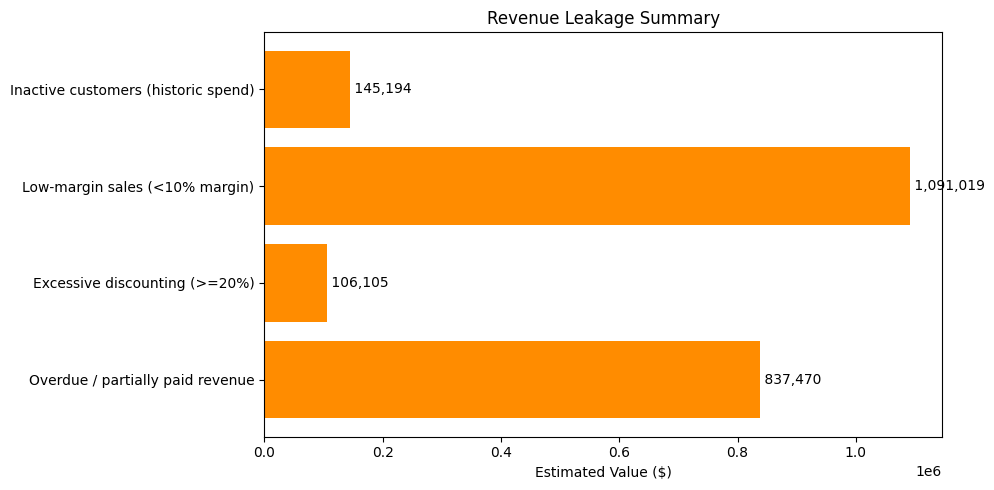

In [43]:
# --- Leakage summary rollup ---
leakage_summary = pd.DataFrame([
    {"leakage_area": "Overdue / partially paid revenue", "estimated_value": round(total_overdue, 2)},
    {"leakage_area": "Excessive discounting (>=20%)", "estimated_value": round(excess_disc_value, 2)},
    {"leakage_area": "Low-margin sales (<10% margin)", "estimated_value": round(low_margin_summary["net_revenue"].sum(), 2)},
    {"leakage_area": "Inactive customers (historic spend)", "estimated_value": round(inactive["total_spend"].sum(), 2)},
])
display(leakage_summary)

fig, ax = plt.subplots()
ax.barh(leakage_summary["leakage_area"], leakage_summary["estimated_value"], color="darkorange")
ax.set_xlabel("Estimated Value ($)")
ax.set_title("Revenue Leakage Summary")
for i, v in enumerate(leakage_summary["estimated_value"]):
    ax.text(v, i, f" {v:,.0f}", va="center")
plt.tight_layout()
plt.show()